In [34]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
import torch
import torch.nn.functional as F
%matplotlib inline

In [35]:
# read in all the words
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [36]:
len(words)

32033

In [37]:
#build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = { s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [38]:
#build the dataset
block_size = 3 #context length:how many characters do we take to predict the next one?
def build_dataset(words):
    X,Y = [],[]
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [62]:
#MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(214783647)
C = torch.randn((vocab_size,n_embd),               generator = g) # 27 * 10,每个单词有一个1*10的概率
W1 = torch.randn((n_embd * block_size,n_hidden),   generator = g) * (5/3 * ( n_embd * block_size )**0.5)     #权重矩阵 30 * 200 ，解决tanh过度饱和的问题
b1 = torch.randn(n_hidden,                         generator = g) * 0.01
W2 = torch.randn((n_hidden,vocab_size),            generator = g) * 0.01  # 解决softmax过度自信的问题
b2 = torch.randn(vocab_size,                       generator = g) * 0.01

#批量归一化中的缩放与平移参数
bngain = torch.ones((1,n_hidden))
bnbias = torch.ones((1,n_hidden))

# 在模型生成期间计算批量归一化参数的方法，同样也可在模型生成后统一计算批量归一化参数
bnmean_running = torch.zeros((1,n_hidden))
bnstd_running = torch.ones((1,n_hidden))

parameters = [C,W1,b1,W2,b2,bngain,bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True #注意不能写成require


12297


tensor(-0.0099) tensor(1.0059)
tensor(0.0015) tensor(1.0344)


(array([4.21430712e-05, 0.00000000e+00, 4.21430712e-05, 1.26429214e-04,
        1.05357678e-04, 5.05716855e-04, 4.63573784e-04, 9.90362174e-04,
        1.64357978e-03, 2.78144270e-03, 3.58216106e-03, 6.89039215e-03,
        1.21793476e-02, 1.88590244e-02, 2.84465731e-02, 4.45452263e-02,
        6.56378335e-02, 1.01775517e-01, 1.40462856e-01, 1.92151333e-01,
        2.52057709e-01, 3.08740140e-01, 3.67150437e-01, 3.99326672e-01,
        4.10958159e-01, 3.98336309e-01, 3.53369652e-01, 2.96961152e-01,
        2.33451543e-01, 1.79381983e-01, 1.29863874e-01, 9.02493871e-02,
        6.22453162e-02, 4.08577076e-02, 2.73087102e-02, 1.69415146e-02,
        1.13575577e-02, 5.33109851e-03, 3.77180488e-03, 2.23358278e-03,
        1.22214907e-03, 8.63932961e-04, 4.00359177e-04, 3.37144570e-04,
        1.47500749e-04, 1.05357678e-04, 6.32146069e-05, 0.00000000e+00,
        0.00000000e+00, 4.21430712e-05]),
 array([-5.78466988, -5.54738295, -5.31009602, -5.07280909, -4.83552216,
        -4.59823523, 

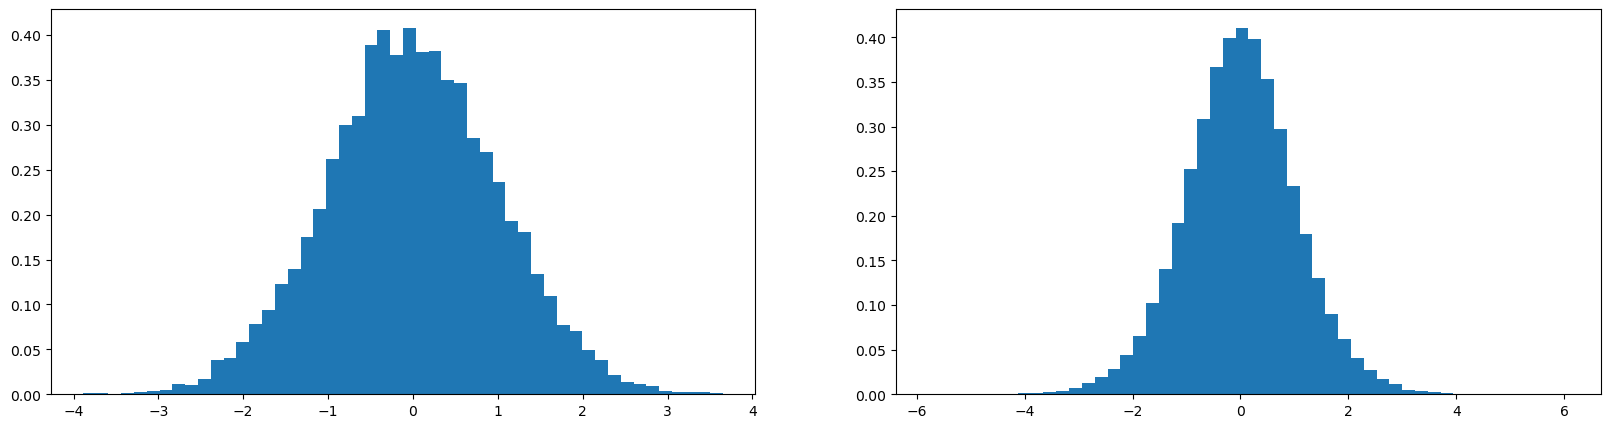

In [63]:
# 模型初始化过程中如何保持标准正态分布，如何初始化权重 ,相关网页链接：https://docs.pytorch.org/docs/stable/nn.init.html
x = torch.randn(1000,10)
w = torch.randn(10,200) / 10**0.5
y = x @ w
print(x.mean(),x.std())
print(y.mean(),y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(),50,density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(),50,density=True)

In [64]:
#same optimization as last time
max_steps = 200000
c
lossi = []

for i in range(max_steps):
    #minbatch construct
    ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator = g)
    Xb,Yb = Xtr[ix],Ytr[ix] #batch X,Y

    #forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0],-1) #concatenate the vectors
    hpreact = embcat @ W1 +b1 # hidden layer pre-activation  》》》》》》》》==========》此处的b1项实际没有什么用，在后续计算均值后被减去 ======================《《《《《
    #hpreact = bngain * (hpreact - hpreact.mean(0,keepdim = True))/hpreact.std(0,keepdim =True) + bnbias  #批量归一化方法，使得输入保持标准高斯分布
    bnmeani = hpreact.mean(0,keepdim=True)
    bnstdi = hpreact.std(0,keepdim = True)
    hpreact = bngain * (hpreact - bnmeani)/(bnstdi+0.000001) + bnbias # 添加0.000001，防止出现除数为0的情况
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 #output layer
    loss = F.cross_entropy(logits,Yb) # loss function

    #在优化过程中计算批量归一化参数
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()


    #update
    lr  = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}:{loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000:3.2568
  10000/ 200000:2.3317
  20000/ 200000:2.1988
  30000/ 200000:1.9143
  40000/ 200000:2.1343
  50000/ 200000:2.4583
  60000/ 200000:2.3638
  70000/ 200000:2.0441
  80000/ 200000:2.0696
  90000/ 200000:1.9518
 100000/ 200000:2.1098
 110000/ 200000:2.4277
 120000/ 200000:2.4070
 130000/ 200000:2.0457
 140000/ 200000:2.5148
 150000/ 200000:2.4904
 160000/ 200000:1.8853
 170000/ 200000:1.9682
 180000/ 200000:2.0342
 190000/ 200000:2.0564


In [ ]:
# 常见的激活函数
# sigmoid,leaky relu,tanh,maxout,relu,elu

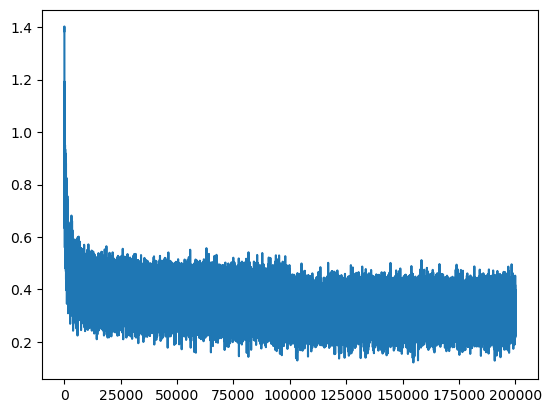

In [41]:
plt.plot(lossi)

In [58]:
# calibrate the batch norm at the end of training，在模型生成后统一计算批量归一化参数
with torch.no_grad():
    #pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0],-1)
    hpreact = embcat @ W1 + b1
    #measure the mean/std over the entire trainging set
    bnmean = hpreact.mean(0,keepdim = True)
    bnstd = hpreact.std(0,keepdim = True)

In [59]:
# 在模型生成后计算批量归一化参数
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
        'train':(Xtr,Ytr),
        'val':(Xdev,Ydev),
        'test':(Xte,Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0],-1)
    hpreact = embcat @ W1 +b1 # hidden layer pre-activation
    #hpreact = bngain * (hpreact - hpreact.mean(0,keepdim = True))/hpreact.std(0,keepdim =True) + bnbias  #批量归一化方法，使得输入保持标准高斯分布
    hpreact = bngain * (hpreact - bnmean)/bnstd + bnbias
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,y)
    print(split,loss.item())

split_loss('train')
split_loss('val')


train 2.1728274822235107
val 2.18904447555542


In [ ]:
#在模型生成期间计算批量归一化参数
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
        'train':(Xtr,Ytr),
        'val':(Xdev,Ydev),
        'test':(Xte,Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0],-1)
    hpreact = embcat @ W1 +b1 # hidden layer pre-activation
    #hpreact = bngain * (hpreact - hpreact.mean(0,keepdim = True))/hpreact.std(0,keepdim =True) + bnbias  #批量归一化方法，使得输入保持标准高斯分布
    hpreact = bngain * (hpreact - bnmean_runing)/bnstd_running  + bnbias
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,y)
    print(split,loss.item())

split_loss('train')
split_loss('val')

In [43]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        #forward pass
        emb = C[torch.tensor([context])] # (1,block_size,n_embd)
        h = torch.tanh(emb.view(1,-1)@ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits,dim = 1)
        #sample from the distribution
        ix =torch.multinomial(probs,num_samples = 1,generator = g).item()
        #shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token,break
        if ix == 0:
            break
    print(''.join(itos[i] for i in out)) #decode and print the generated word

carpa.
zamille.
khi.
mili.
taty.
salaysie.
rahnen.
delynn.
jareei.
ner.
kia.
chaiif.
kaleigh.
ham.
poce.
quintharline.
liveni.
wayelon.
jaryni.
jaxeenicud.
